<a href="https://colab.research.google.com/github/the-lazyguy/brain-tumor-xai/blob/main/Brain_Tumor_EfficientNet_GradCAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Detection with EfficientNetB0, Grad-CAM and Evaluation


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import EfficientNetB0

DATASET_PATH='/content/drive/MyDrive/brain_tumor_dataset'
IMG_SIZE=224
BATCH_SIZE=32

In [ ]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE)

val_ds=tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE)

class_names=train_ds.class_names
print(class_names)

Found 3264 files belonging to 2 classes.
Using 2612 files for training.
Found 3264 files belonging to 2 classes.
Using 652 files for validation.
['Testing', 'Training']


In [ ]:
base_model=EfficientNetB0(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False

inputs=tf.keras.Input(shape=(224,224,3))
x=tf.keras.layers.Rescaling(1./255)(inputs)
x=base_model(x,training=False)
x=tf.keras.layers.GlobalAveragePooling2D()(x)
x=tf.keras.layers.Dropout(0.5)(x)
outputs=tf.keras.layers.Dense(len(class_names),activation='softmax')(x)

final_model=tf.keras.Model(inputs,outputs)
final_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
final_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
early_stop=callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
reduce_lr=callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.2,patience=2)

history=final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 615s 7s/step - accuracy: 0.8694 - loss: 0.4006 - val_accuracy: 0.9034 - val_loss: 0.3220 - learning_rate: 0.0010
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 0.8733 - loss: 0.3850 - val_accuracy: 0.9034 - val_loss: 0.3249 - learning_rate: 0.0010
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 159ms/step - accuracy: 0.8733 - loss: 0.3863 - val_accuracy: 0.9034 - val_loss: 0.3480 - learning_rate: 0.0010
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.8733 - loss: 0.3864 - val_accuracy: 0.9034 - val_loss: 0.3214 - learning_rate: 2.0000e-04
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - accuracy: 0.8733 - loss: 0.3882 - val_accuracy: 0.9034 - val_loss: 0.3204 - learning_rate: 2.0000e-04
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.8733 - loss: 0.3887 - val_accuracy: 0.9034 - val_loss: 0.3200 - learning_rate: 2.0000e-04
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - accuracy: 0.8733 

In [ ]:
final_model.save('/content/drive/MyDrive/brain_tumor_model.keras')

## Evaluation

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
y_true=np.concatenate([y.numpy() for _,y in val_ds])
y_pred=np.argmax(final_model.predict(val_ds),axis=1)

print(classification_report(y_true,y_pred,target_names=class_names))
print(confusion_matrix(y_true,y_pred))

21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 471ms/step
              precision    recall  f1-score   support

     Testing       0.00      0.00      0.00        63
    Training       0.90      1.00      0.95       589

    accuracy                           0.90       652
   macro avg       0.45      0.50      0.47       652
weighted avg       0.82      0.90      0.86       652

[[  0  63]
 [  0 589]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Grad-CAM

In [ ]:

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model):

    base_model = model.get_layer("efficientnetb0")

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            base_model.get_layer("top_conv").output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) > 0:
        heatmap = heatmap / tf.reduce_max(heatmap)

    return heatmap.numpy()

img_path='/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (625).jpg'

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img,(224,224))
input_image = np.expand_dims(img_resized.astype("float32"), axis=0)

heatmap = make_gradcam_heatmap(input_image, final_model)

plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.show()


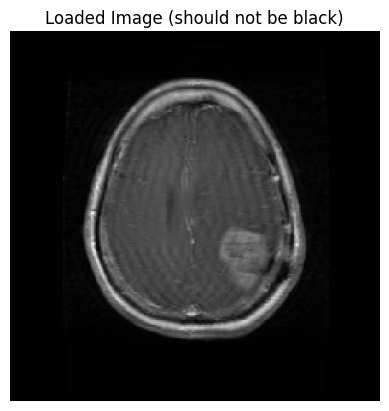

input_image_tensor shape: (1, 224, 224, 3)
input_image_tensor dtype: <dtype: 'float32'>
input_image_tensor max value: 253.0
input_image_tensor min value: 0.0


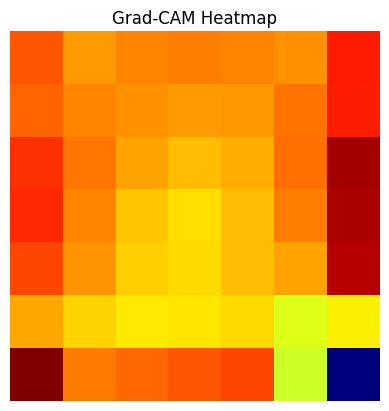

In [ ]:
# Fixed Grad-CAM implementation moved to previous cell.

## Future Segmentation (U-Net Placeholder)
Use a segmentation dataset with masks and train a U-Net model.